In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('job_salary_prediction_dataset1.csv')
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734


In [4]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [5]:
print(df.mean(numeric_only=True))

experience_years        10.006247
skills_count             9.999133
certifications           2.494197
salary              117510.722696
dtype: float64


In [6]:
df.fillna(0)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,0,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [7]:
df.count()

job_title           250000
experience_years    249398
education_level     249485
skills_count        249174
industry            250000
company_size        249040
location            248931
remote_work         250000
certifications      249425
salary              250000
dtype: int64

In [8]:
df.median(numeric_only=True)

experience_years        10.0
skills_count            10.0
certifications           3.0
salary              117504.0
dtype: float64

In [9]:
df.shape

(250000, 10)

In [10]:
df.loc[2,'experience_years']

np.float64(18.0)

In [11]:
#datatypes and info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         250000 non-null  str    
 1   experience_years  249398 non-null  float64
 2   education_level   249485 non-null  str    
 3   skills_count      249174 non-null  float64
 4   industry          250000 non-null  str    
 5   company_size      249040 non-null  str    
 6   location          248931 non-null  str    
 7   remote_work       250000 non-null  str    
 8   certifications    249425 non-null  float64
 9   salary            250000 non-null  int64  
dtypes: float64(3), int64(1), str(6)
memory usage: 30.7 MB


In [12]:
#statitical summary
df.describe()

,experience_years,skills_count,certifications,salary
count,249398.000000,249174.000000,249425.000000,250000.000000
mean,10.006247,9.999133,2.494197,117510.722696
std,6.060365,5.463778,1.703118,38385.455248
min,0.000000,1.000000,0.000000,14139.000000
25%,5.000000,5.000000,1.000000,89666.750000
50%,10.000000,10.000000,3.000000,117504.000000
75%,15.000000,15.000000,4.000000,145491.500000
max,20.000000,19.000000,5.000000,220977.000000


In [13]:
#unique values in each col
df.nunique()

job_title               12
experience_years        21
education_level          5
skills_count            19
industry                10
company_size             5
location                10
remote_work              3
certifications           6
salary              122358
dtype: int64

In [14]:
#check categorical columns mannualy
print(df['company_size'].unique())

<ArrowStringArray>
['Medium', 'Small', nan, 'Large', 'Enterprise', 'Startup']
Length: 6, dtype: str


In [15]:
#missing values
df.isnull().sum()

job_title              0
experience_years     602
education_level      515
skills_count         826
industry               0
company_size         960
location            1069
remote_work            0
certifications       575
salary                 0
dtype: int64

In [16]:
#duplicate rows
df.duplicated().sum()

np.int64(0)

In [17]:
df['remote_work']=df['remote_work'].fillna(df['remote_work'].mode()[0])
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [18]:
df['certifications']=df['certifications'].fillna(df['certifications'].mode()[0])
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [19]:
df['salary']=df['salary'].fillna(df['salary'].median())
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [20]:
df['company_size']

0             Medium
1              Small
2                NaN
3             Medium
4              Large
             ...    
249995    Enterprise
249996       Startup
249997    Enterprise
249998         Small
249999        Medium
Name: company_size, Length: 250000, dtype: str

In [21]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['experience_years', 'skills_count', 'certifications', 'salary'], dtype='str')

In [22]:
#set fig size
plt.figure(figsize=(18,12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

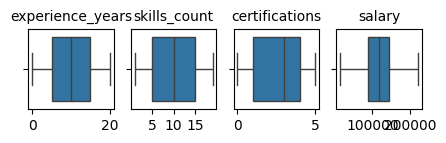

In [23]:
#loop and create sub plots
for i , col in enumerate(num_cols,1):
    plt.subplot(4,5,i)
    sns.boxplot(x=df[col])
    plt.title(col,fontsize=10)
    plt.xlabel('')

In [24]:
#adjust layout
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [25]:
#add main title
plt.suptitle('boxplots for detecting outliers', fontsize=18, y=1.02)
plt.savefig ('boxplot.png')
plt.show()

<Figure size 640x480 with 0 Axes>

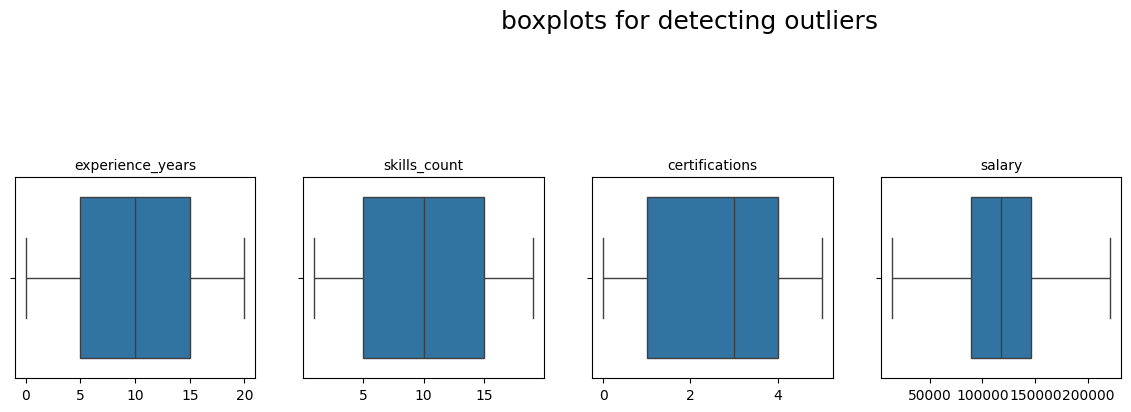

In [26]:
#set fig size
plt.figure(figsize=(18,12))

#loop and create sub plots
for i , col in enumerate(num_cols,1):
    plt.subplot(4,5,i)
    sns.boxplot(x=df[col])
    plt.title(col,fontsize=10)
    plt.xlabel('')

#add main title
plt.suptitle('boxplots for detecting outliers', fontsize=18, y=1.02)
plt.savefig ('boxplot.png')
plt.show()

In [27]:
Q1=df['experience_years'].quantile(0.25)
Q3=df['experience_years'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df['experience_years']=np.where(df['experience_years']>upper,upper,df['experience_years'])
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [28]:
Q1=df['skills_count'].quantile(0.25)
Q3=df['skills_count'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df['skills_count']=np.where(df['skills_count']<lower,lower,df['skills_count'])
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [29]:
plt.style.use('fivethirtyeight')
sns.set_palette('Set2')

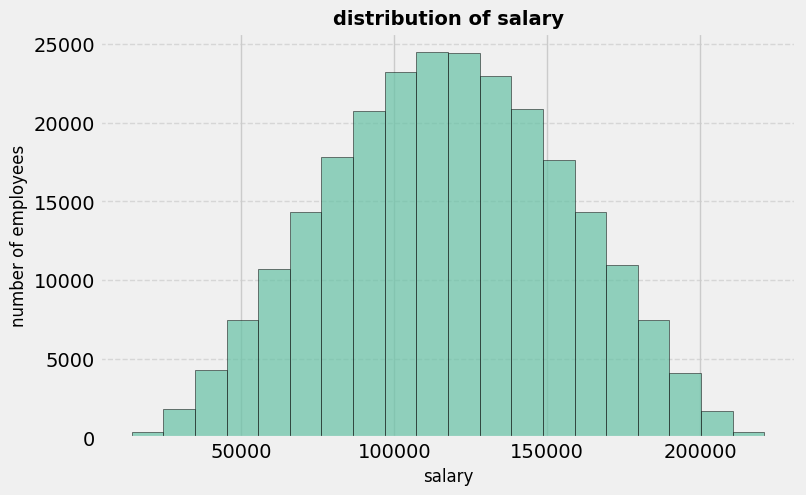

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df['salary'],bins=20,edgecolor='black',alpha=0.7)
plt.title('distribution of salary', fontsize=14, fontweight='bold')
plt.xlabel('salary', fontsize=12)
plt.ylabel('number of employees', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

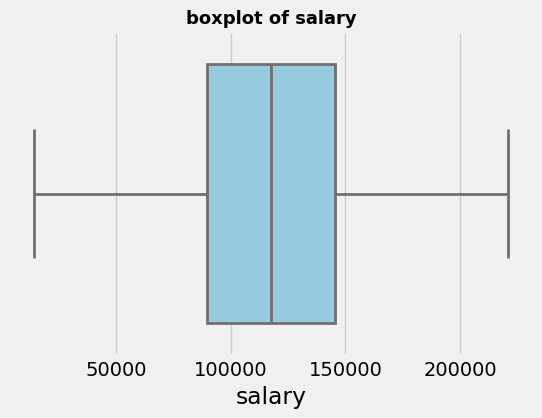

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['salary'], color='skyblue', linewidth=2)
plt.title('boxplot of salary', fontsize=13, fontweight='bold')
plt.show()

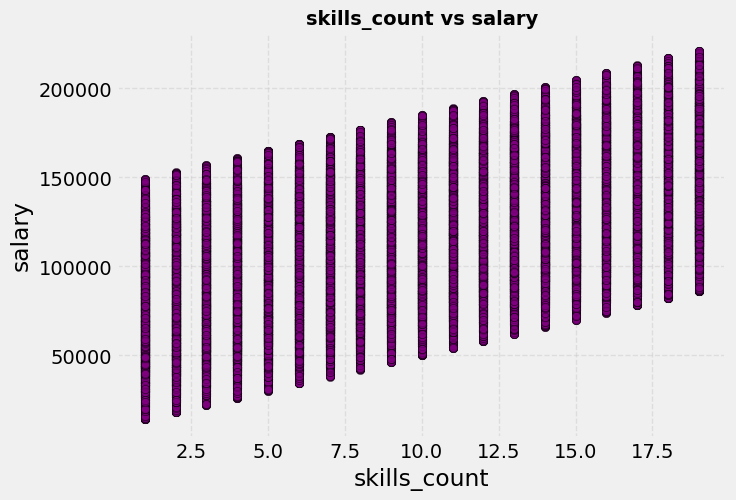

In [32]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['skills_count'],
    df['salary'],
    color='purple',
    alpha=0.6,
    edgecolor='black'
)

plt.title('skills_count vs salary', fontsize=14, fontweight='bold')
plt.xlabel('skills_count')
plt.ylabel('salary')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

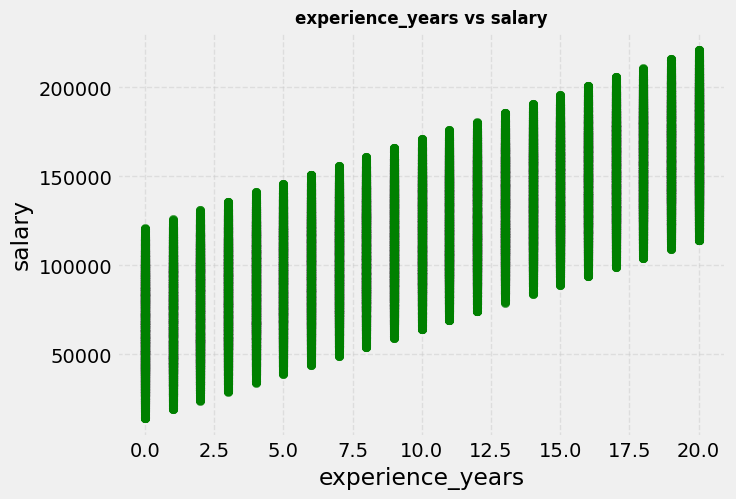

In [33]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['experience_years'],
    df['salary'],
    color='green',
    alpha=0.6
)

plt.title('experience_years vs salary', fontsize=12, fontweight='bold')
plt.xlabel('experience_years')
plt.ylabel('salary')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

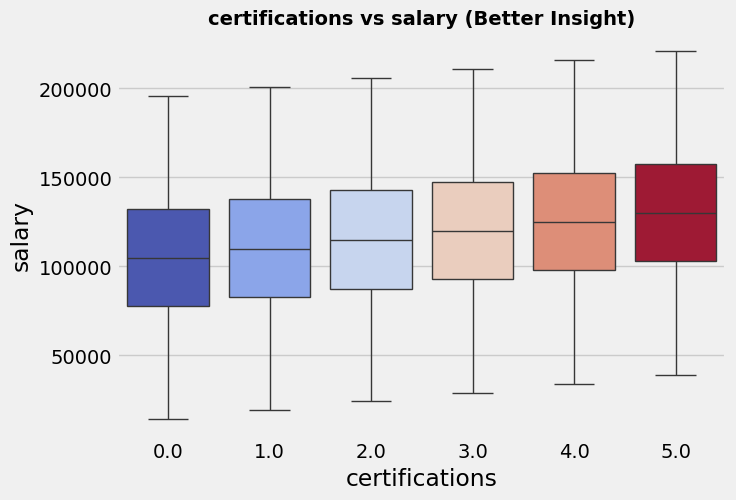

In [34]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='certifications',
    y='salary',
    hue='certifications',
    data=df,
    palette='coolwarm',
    legend=False
)

plt.title('certifications vs salary (Better Insight)', fontsize=14, fontweight='bold')

plt.show()

<Axes: xlabel='skills_count', ylabel='experience_years'>

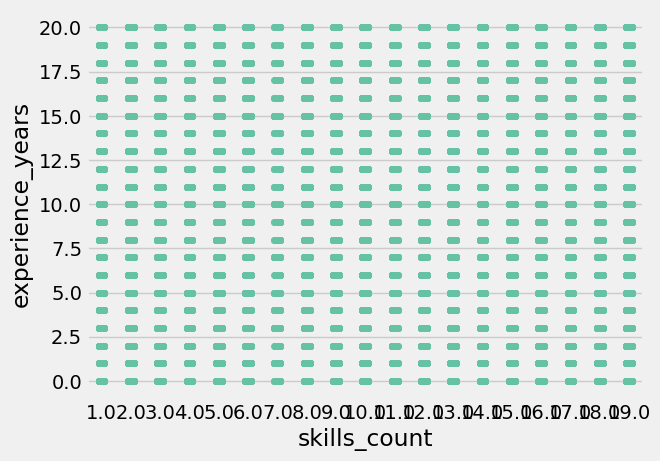

In [35]:
sns.stripplot(
    x='skills_count',
    y='experience_years',
    data=df,
    jitter=True
)

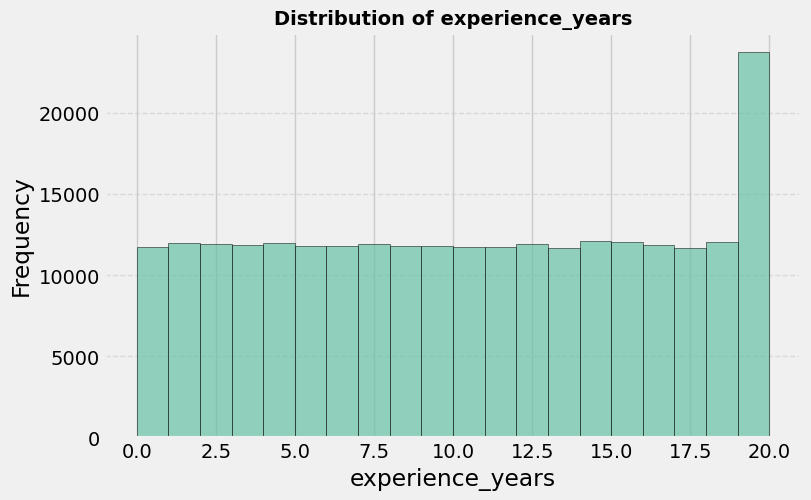

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(df['experience_years'], bins=20, edgecolor='black', alpha=0.7)

plt.title("Distribution of experience_years", fontsize=14, fontweight='bold')
plt.xlabel("experience_years")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

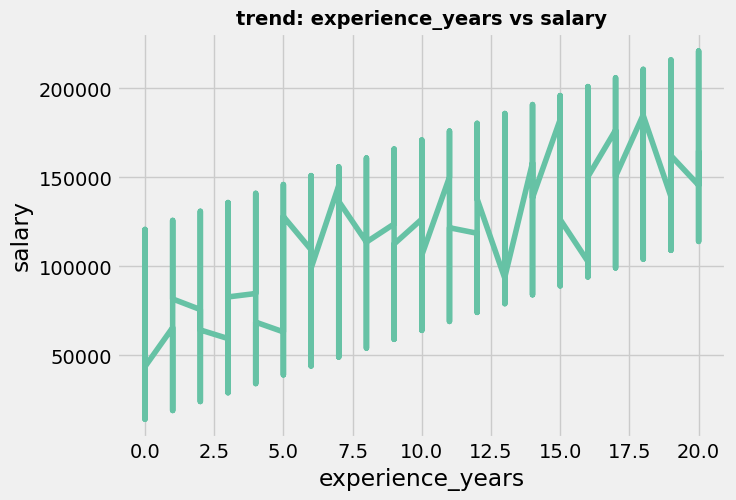

In [37]:
sorted_df=df.sort_values(by='experience_years')
plt.figure(figsize=(7,5))
plt.plot(sorted_df['experience_years'], sorted_df['salary'])
plt.title('trend: experience_years vs salary', fontsize=14, fontweight='bold')
plt.xlabel('experience_years')
plt.ylabel('salary')
plt.grid(True)
plt.show()

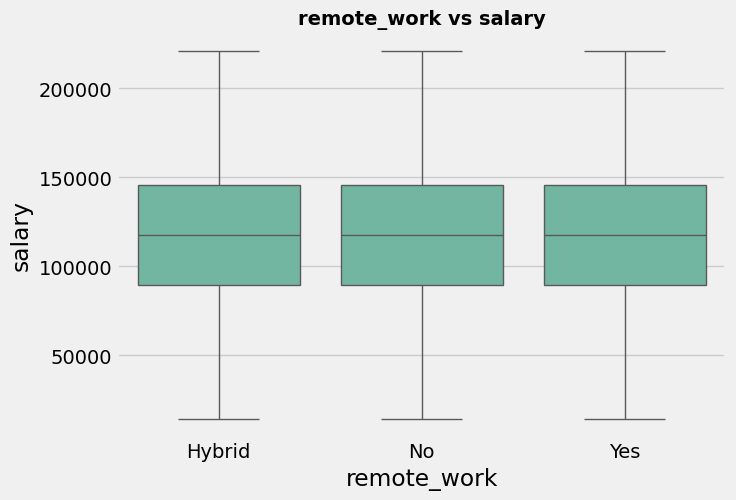

In [38]:
plt.figure(figsize=(7,5))
sns.boxplot(x='remote_work', y='salary', data=df)
plt.title('remote_work vs salary', fontsize=14, fontweight='bold')
plt.show()

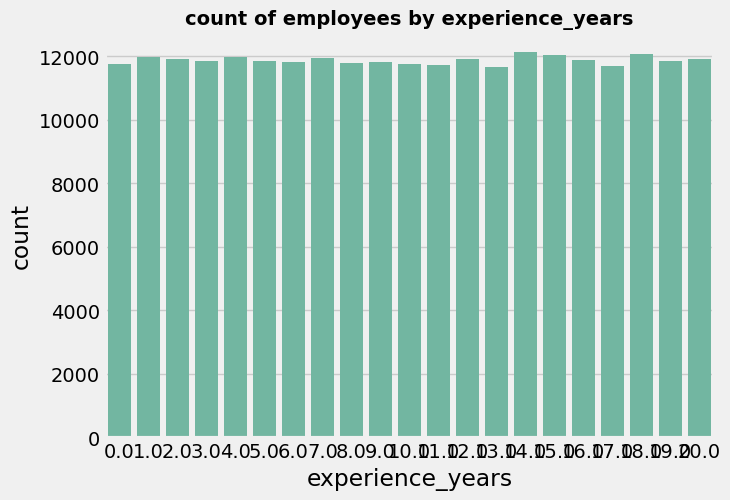

In [39]:
plt.figure(figsize=(7,5))
sns.countplot(x='experience_years', data=df)
plt.title('count of employees by experience_years', fontsize=14, fontweight='bold')
plt.show()

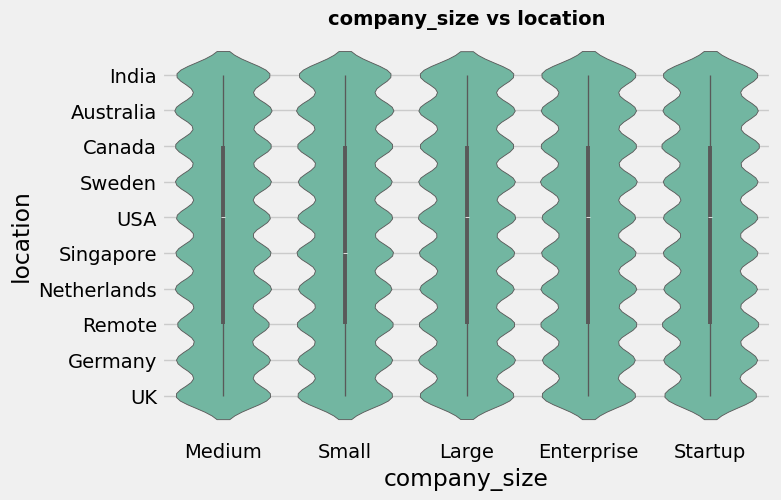

In [40]:
plt.figure(figsize=(7,5))
sns.violinplot(
    x='company_size',
    y='location', 
    data=df,
    inner='box'
)
plt.title('company_size vs location',fontsize=14, fontweight='bold' )
plt.show()

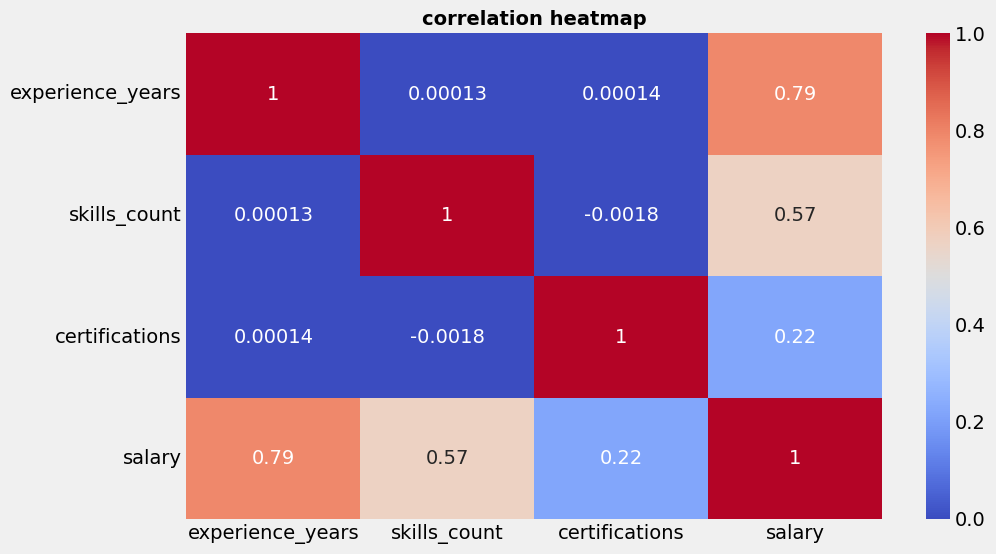

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('correlation heatmap', fontsize=14, fontweight='bold' )
plt.show()

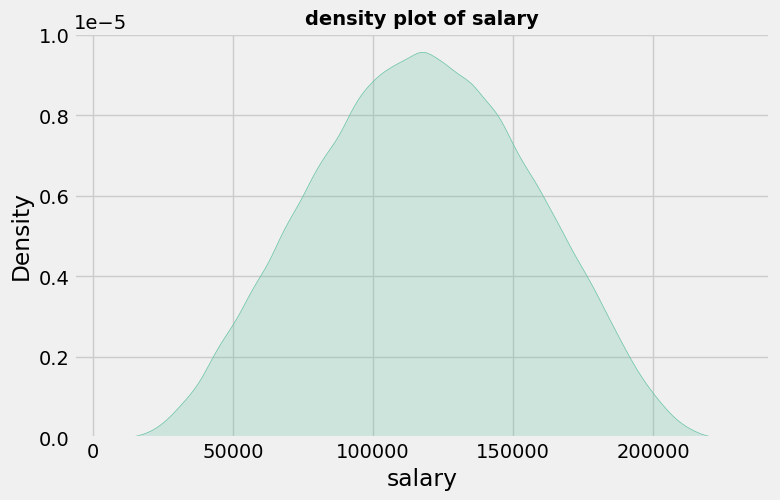

In [42]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['salary'], fill=True)
plt.title('density plot of salary', fontsize=14, fontweight='bold')
plt.show()

In [43]:
df.corr(numeric_only=True)['salary'].sort_values(ascending=False)

salary              1.000000
experience_years    0.788856
skills_count        0.568918
certifications      0.220713
Name: salary, dtype: float64

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
import pandas as pd
import numpy as np

# Loading the dataset with the specific filename
df = pd.read_csv('job_salary_prediction_dataset1.csv')

# Checking the first few rows to verify data loading
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734


In [46]:
# Checking dataset structure and data types
print(df.info())

# Summary statistics for numerical columns
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         250000 non-null  str    
 1   experience_years  249398 non-null  float64
 2   education_level   249485 non-null  str    
 3   skills_count      249174 non-null  float64
 4   industry          250000 non-null  str    
 5   company_size      249040 non-null  str    
 6   location          248931 non-null  str    
 7   remote_work       250000 non-null  str    
 8   certifications    249425 non-null  float64
 9   salary            250000 non-null  int64  
dtypes: float64(3), int64(1), str(6)
memory usage: 30.7 MB
None
       experience_years   skills_count  certifications         salary
count     249398.000000  249174.000000   249425.000000  250000.000000
mean          10.006247       9.999133        2.494197  117510.722696
std            6.060365       5.463778        1.70

In [47]:
# Checking dataset structure and data types
print(df.info())

# Summary statistics for numerical columns
print(df.describe())

# Checking for unique values in categorical columns
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         250000 non-null  str    
 1   experience_years  249398 non-null  float64
 2   education_level   249485 non-null  str    
 3   skills_count      249174 non-null  float64
 4   industry          250000 non-null  str    
 5   company_size      249040 non-null  str    
 6   location          248931 non-null  str    
 7   remote_work       250000 non-null  str    
 8   certifications    249425 non-null  float64
 9   salary            250000 non-null  int64  
dtypes: float64(3), int64(1), str(6)
memory usage: 30.7 MB
None
       experience_years   skills_count  certifications         salary
count     249398.000000  249174.000000   249425.000000  250000.000000
mean          10.006247       9.999133        2.494197  117510.722696
std            6.060365       5.463778        1.70

In [48]:
# Checking for null values
print(df.isnull().sum())

# Dropping missing values to ensure quality analysis
df.dropna(inplace=True)

# Checking for and removing duplicate records
print(f"Duplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Verifying the final cleaned data count
print(df.shape)

job_title              0
experience_years     602
education_level      515
skills_count         826
industry               0
company_size         960
location            1069
remote_work            0
certifications       575
salary                 0
dtype: int64
Duplicates found: 0
(245497, 10)


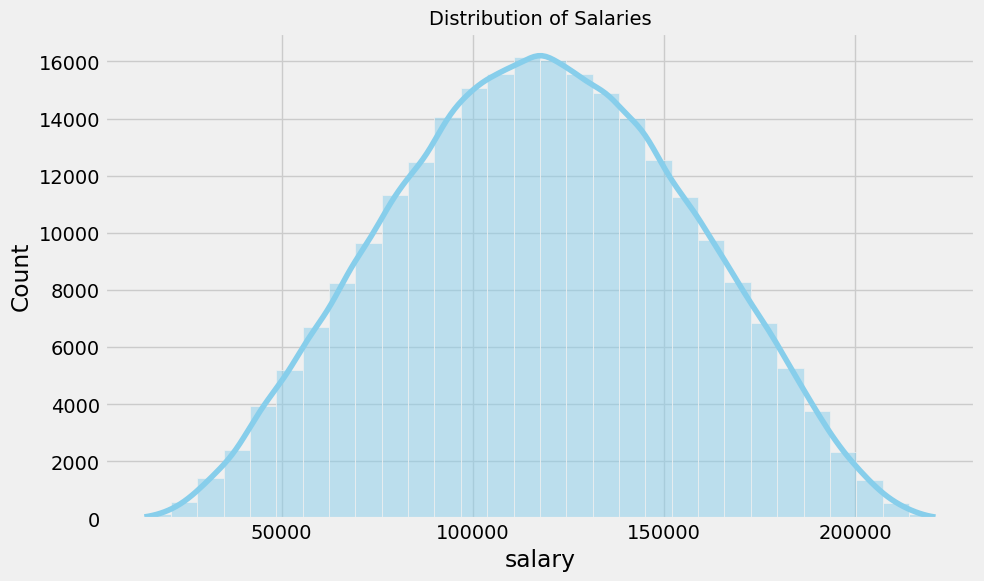

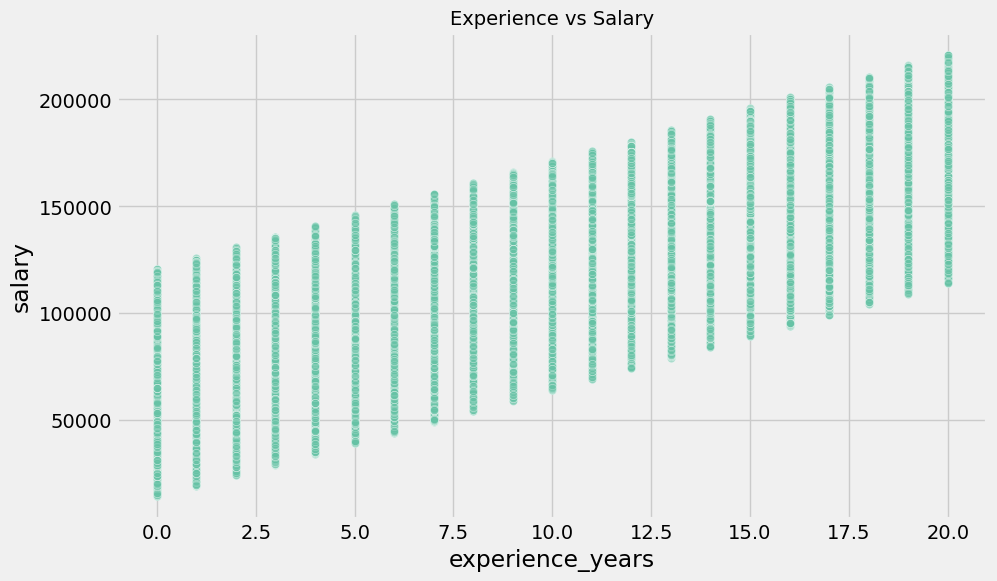

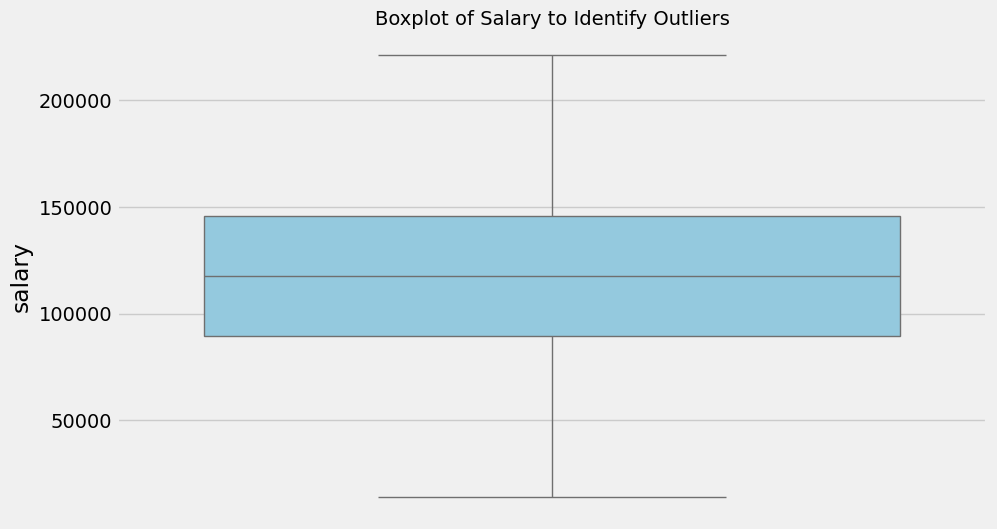

C:\Users\ma018\AppData\Local\Temp\ipykernel_22264\1929445706.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='certifications', y='salary', data=df, palette='coolwarm')


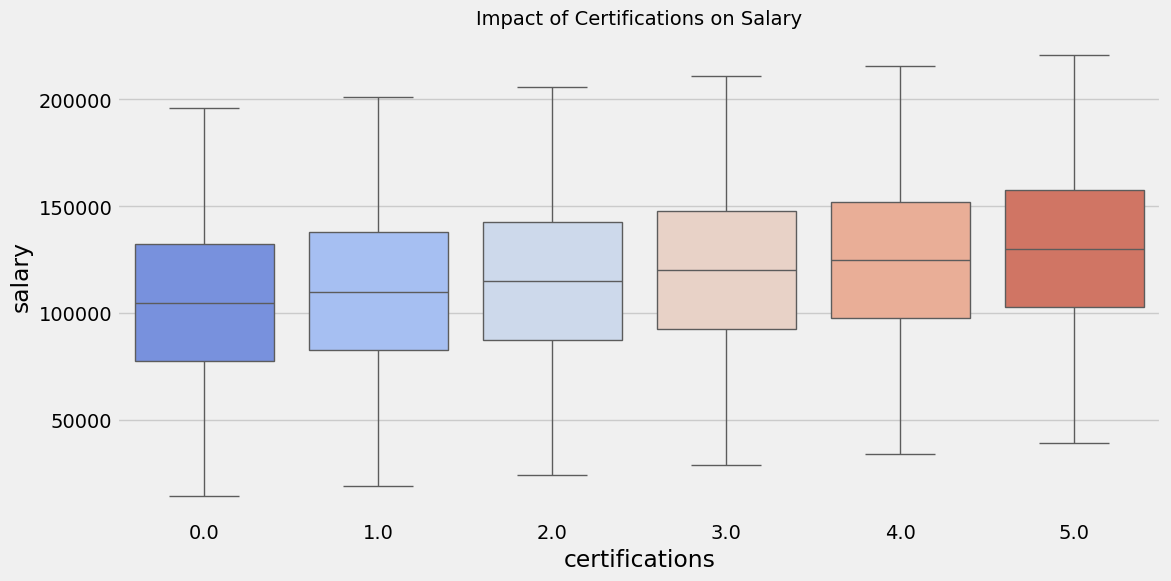

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Salary Distribution (Histogram)
plt.figure(figsize=(10,6))
sns.histplot(df['salary'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Salaries', fontsize=14)
plt.show()

# 2. Experience vs Salary (Scatter Plot)
plt.figure(figsize=(10,6))
sns.scatterplot(x='experience_years', y='salary', data=df, alpha=0.5)
plt.title('Experience vs Salary', fontsize=14)
plt.show()

# 3. Salary Outliers (Boxplot)
plt.figure(figsize=(10,6))
sns.boxplot(y=df['salary'], color='skyblue')
plt.title('Boxplot of Salary to Identify Outliers', fontsize=14)
plt.show()

# 4. Certifications vs Salary (Grouped Boxplot)
plt.figure(figsize=(12,6))
sns.boxplot(x='certifications', y='salary', data=df, palette='coolwarm')
plt.title('Impact of Certifications on Salary', fontsize=14)
plt.show()

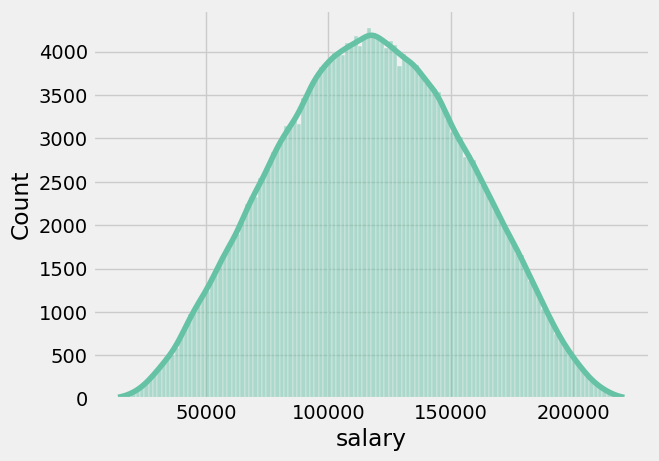

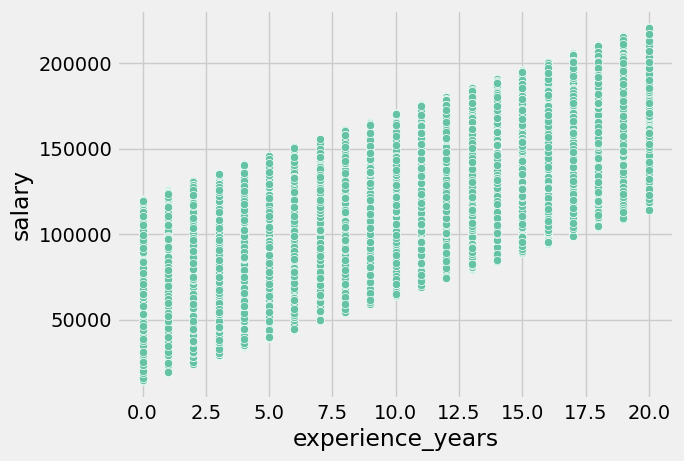

In [50]:
# Code for Histogram and Scatter Plot
sns.histplot(df['salary'], kde=True)
plt.show()
sns.scatterplot(x='experience_years', y='salary', data=df)
plt.show()

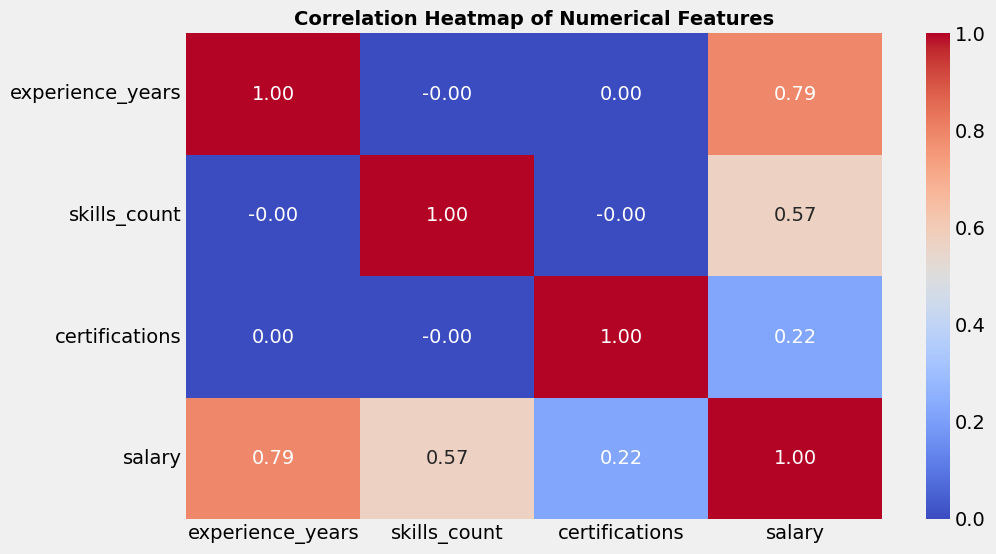

In [51]:
# Generating the Correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

In [52]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# =========================
# REDUCE SIZE (OPTIONAL)
# =========================
df = df.sample(n=50000, random_state=42)

# =========================
# FEATURE ENGINEERING
# =========================
df['exp_squared'] = df['experience_years'] ** 2
df['skill_per_exp'] = df['skills_count'] / (df['experience_years'] + 1)
df['cert_per_skill'] = df['certifications'] / (df['skills_count'] + 1)

df['seniority'] = pd.cut(
    df['experience_years'],
    bins=[0, 2, 5, 10, 20],
    labels=['Fresher', 'Junior', 'Mid', 'Senior']
)

# =========================
# ENCODING
# =========================
cat_cols = ['job_title', 'education_level', 'location', 'industry',
            'company_size', 'remote_work', 'seniority']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# =========================
# FEATURES & TARGET
# =========================
X = df.drop('salary', axis=1)
y = df['salary']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# SCALING (NUMERIC ONLY)
# =========================
num_cols = ['experience_years', 'skills_count', 'certifications',
            'exp_squared', 'skill_per_exp', 'cert_per_skill']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# =========================
# TRAIN KNN
# =========================
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
y_pred = knn.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("🔹 Model Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)

# =========================
# SAVE EVERYTHING
# =========================
pickle.dump(knn, open("knn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("✅ Model ready for deployment!")

🔹 Model Performance
R2 Score: 0.9582368148710748
MAE: 6260.720257142857
MSE: 61767716.27452654
✅ Model ready for deployment!


In [53]:
# =========================
# IMPORT LIBRARIES
# =========================
import pickle
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# TRAIN MODEL
# =========================
knn = KNeighborsRegressor(n_neighbors=3)

knn.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = knn.predict(X_test)

# =========================
# EVALUATION
# =========================
print("🔹 KNN Model Performance")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# =========================
# SAVE MODEL
# =========================
pickle.dump(knn, open("knn_model.pkl", "wb"))

🔹 KNN Model Performance
R2 Score: 0.9398479277233543
MAE: 7509.2189
MSE: 88964865.16147779
